$$\Large \begin{equation*}
  \begin{cases}
    \dot x = ax - xy
   \\
    \dot y = bxy - cy
  \end{cases}
\end{equation*} $$

$$x(0) = x_0 > 0,\ \  y(0) = y_0 > 0$$

Вариант 17. Численная схема явная. Порядок точности 3

Шаблон схемы в координатах "время-численность"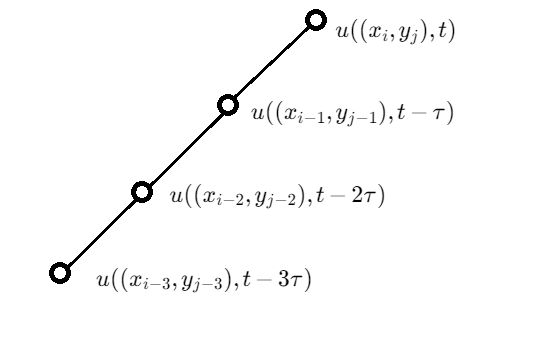

### Рассчёты

$$\large \frac{\partial x}{\partial t} \approx  \frac{1}{\tau} (\alpha_0 x(t-3\tau) + \alpha_1x(t -2\tau) + \alpha_2x(t - \tau) + \alpha_3x(t)) = ax(t - \tau)y(t - \tau) -cy(t - \tau)$$

$$\large \frac{\partial x}{\partial t} \approx  \frac{1}{\tau} (\alpha_0 x(t-3\tau) + \alpha_1x(t -2\tau) + \alpha_2x(t-\tau) + \alpha_3x(t))$$

$$\begin{pmatrix}
  1 & 1 & ... & 1\\
  -l& -l+1 & ...&m\\
  l^2& (l-1)^2 & ...&m^2\\
  (-l)^3& (-l+1)^3 & ...&m^3\\
  ... & ... & ... & ...\\
\end{pmatrix}
\begin{pmatrix}
  a_0 \\
  a_1\\
  a_2\\
  a_3\\
  ... \\
\end{pmatrix}
= \begin{pmatrix}
  0 \\
  1\\
  0\\
  0\\
  ... \\
\end{pmatrix}$$

$$\begin{pmatrix}
  1 & 1 & 1 & 1\\
  -3& -2 & -1&0\\
  9& 4 & 1&0\\
  -27& -8 & -1&0\\
\end{pmatrix}
\begin{pmatrix}
  a_0 \\
  a_1\\
  a_2\\
  a_3\\
  \end{pmatrix}
= \begin{pmatrix}
  0 \\
  1\\
  0\\
  0\\
  \end{pmatrix}$$

$$\begin{pmatrix}
  1 & 1 & 1 & 1 &|0\\
  -3& -2 & -1&0& |1\\
  9& 4 & 1&0&|0\\
  -27& -8 & -1&0&|0\\
\end{pmatrix}=>
\begin{pmatrix}
  1 & 0 & 0 & 0 &|-\frac{1}{3}\\
  0& 1 & 0&0 & |1.5\\
  0& 0 & 1&0 & |-3\\
  0& 0 & 0&1 & |\frac{11}{6}\\
\end{pmatrix}$$

$$\large \frac{\partial x}{\partial t} \approx  \frac{1}{\tau} (-\frac{1}{3} x(t-3\tau) + 1.5x(t -2\tau) -3 x(t-\tau) + \frac{11}{6}x(t))$$

$$\large \frac{1}{\tau} (-\frac{1}{3} x(t-3\tau) + 1.5x(t -2\tau) -3 x(t-\tau) + \frac{11}{6}x(t)) = a(t-\tau)x(t-\tau) -x(t-\tau)y(t-\tau)$$

$$\large  x(t) = \frac{6}{11} \cdot (\tau(a(t-\tau)x(t-\tau) -x(t-\tau)y(t-\tau)) + \frac{1}{3} x(t-3\tau) - 1.5x(t -2\tau) + 3x(t-\tau)) $$

Аналогично и для $y$
$$\large  \frac{1}{\tau} (-\frac{1}{3} y(t-3\tau) + 1.5y(t -2\tau) -3 y(t-\tau) + \frac{11}{6}y(t))= bx(t-\tau)y(t-\tau) -cy(t-\tau)$$

$$\large  y(t) =\frac{6}{11}\cdot (\tau( bx(t-\tau)y(t-\tau) -cy(t-\tau)) + \frac{1}{3} x(t-3\tau) - 1.5x(t -2\tau) + 3x(t-\tau))$$

### Моделирование

In [ ]:
import math as mt
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
w = 0
b = 0.8
c = 2
tau = 0.001
g_0 = 5

a_0 = -1/3 # a_{-2}
a_1 = 1.5  # a_{-1}
a_2 = -3 # a_0
a_3 = 11/6 # a_1
x = [10, 8.9, 7.65]
y = [4, 5.1, 6.35]

iterations = 10000
start_num = 3
a = lambda t: g_0 * (1 + mt.sin(w*t))

In [ ]:
def Сalculation(x, y):
  t_arr = [0, tau, 2*tau]
  t = tau * start_num
  for i in range(start_num, iterations):
      x.append((tau *(a(t-tau)*x[i-1] - x[i-1]*y[i-1]) -a_0*x[i-3] - a_1*x[i-2] - a_2*x[i-1]) / a_3)
      y.append((tau *(b*x[i-1]*y[i-1] - c*y[i-1]) -a_0*y[i-3] - a_1*y[i-2] - a_2*y[i-1]) / a_3)
      t_arr.append(t)
      t = t + tau
  return t_arr


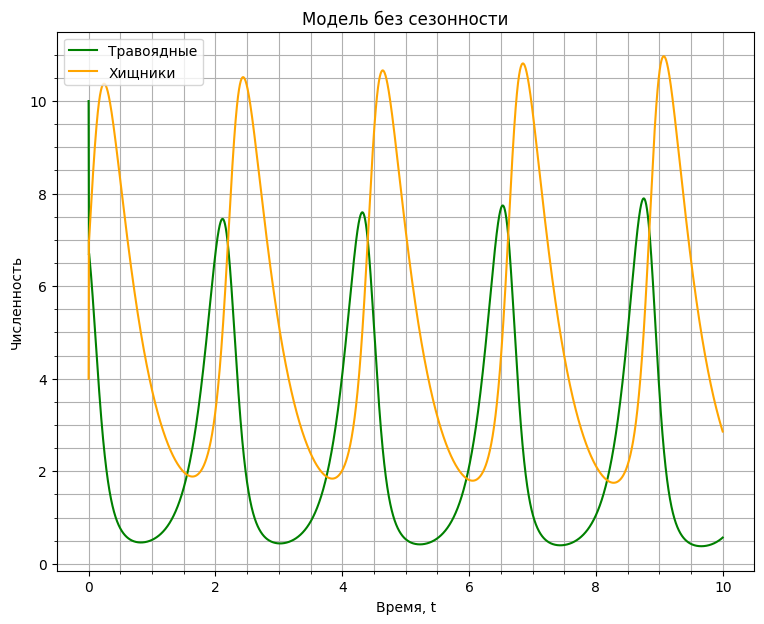

In [ ]:
w = 0
x = [10, 8.98, 7.59]
y = [4, 5.25, 6.37]
t_arr = Сalculation(x, y)
fig = plt.figure(figsize=(9, 7))
ax = fig.subplots(1,1)
ax.grid(True, which='both')
ax.minorticks_on()
ax.plot(t_arr,x, color="green", label="Травоядные")
ax.plot(t_arr,y, color ="orange", label="Хищники")

ax.legend()
ax.set_xlabel("Время, t")
ax.set_ylabel("Численность")
ax.set_title("Модель без сезонности")
plt.savefig('scheme.png')

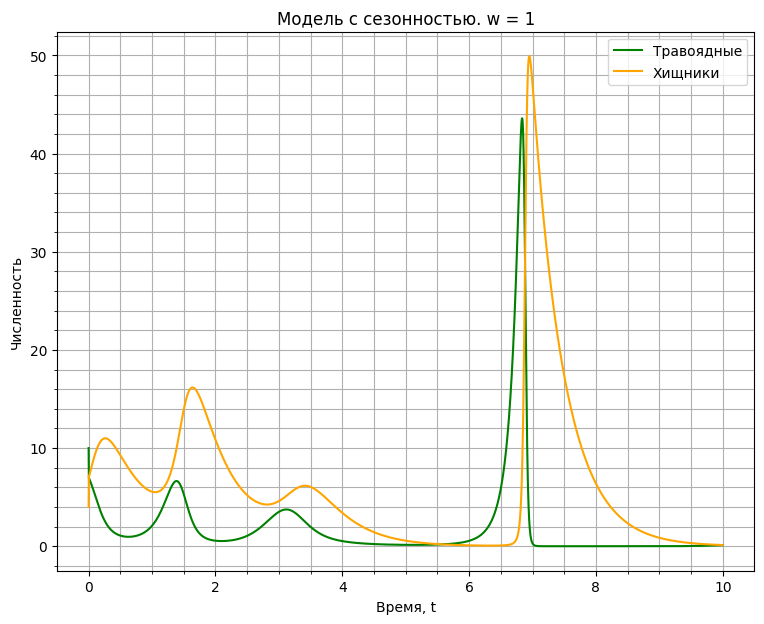

In [ ]:
w = 1
x = [10, 8.9, 7.65]
y = [4, 5.1, 6.35]
t_arr = Сalculation(x, y)
fig = plt.figure(figsize=(9, 7))
ax = fig.subplots(1,1)
ax.grid(True, which='both')
ax.minorticks_on()
ax.plot(t_arr,x, color="green", label="Травоядные")
ax.plot(t_arr,y, color ="orange", label="Хищники")

ax.legend()
ax.set_xlabel("Время, t")
ax.set_ylabel("Численность")
ax.set_title("Модель c сезонностью. w = 1")
plt.savefig('scheme.png')

### Оценка погрешности
##### Погрешность, при разложении в степенной ряд

Отбрасываем: $ x^{(4)}(t)\sum_{k=-3}^{0}{a_k \frac{k^4}{4!}\tau^{3}}$

$$ \sum_{k=-3}^{0}{a_k \frac{k^4}{4!}\tau^{3}} = \tau^3(-\frac{1}{3}\cdot\frac{81}{24} + \frac{3}{2}\cdot\frac{16}{24} -3\cdot\frac{1}{24}) = -\tau^3\frac{1}{4}$$

#### Оценка машинной погрешности

Машинная погрешность = $\Large \frac{ε}{\tau}$

In [ ]:
def get_epsilon():
    epsilon = 1.0
    while (1.0 + epsilon) != 1.0:
        epsilon /= 2.0
    return epsilon * 2.0

machine_epsilon = get_epsilon()
print(f"Машинная погрешность: {machine_epsilon}")
print(f"Машинная погрешность с τ = {tau} : {machine_epsilon / tau}")

Машинная погрешность: 2.220446049250313e-16
Машинная погрешность с τ = 0.001 : 2.220446049250313e-13


Погрешность рассчётов = $\tau^3 \frac{1}{4} + \Large \frac{ε}{\tau}$

#### Графики погрешности

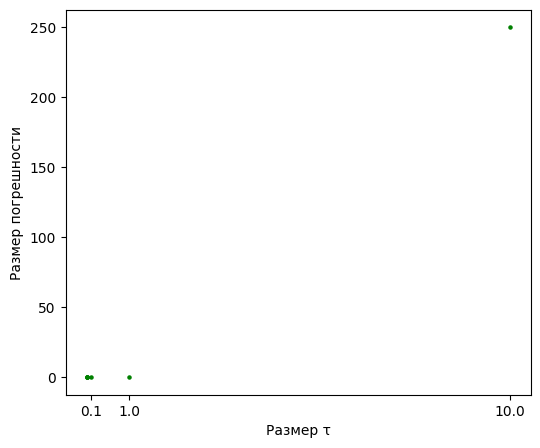

In [ ]:
tau_error = lambda t: float(t**3 /4) + machine_epsilon/tau
tau_start = 100
tau_end = 0.00001
tau_array_10 = np.logspace(1, -5, num=7)
tau_array = [n/100000 for n in range(1, 9000, 1)]
tau_errors_10 = [tau_error(n) for n in tau_array_10]
tau_errors = [tau_error(n) for n in tau_array]
fig = plt.figure(figsize=(6, 5))
ax = fig.subplots(1,1)
ax.set_xlabel("Размер τ")
ax.set_ylabel("Размер погрешности")
ax.scatter(tau_array_10,tau_errors_10, color="green", label="Ошибка", s=5)
plt.xticks([0.1, 1, 10])
plt.savefig('tau_err.png')

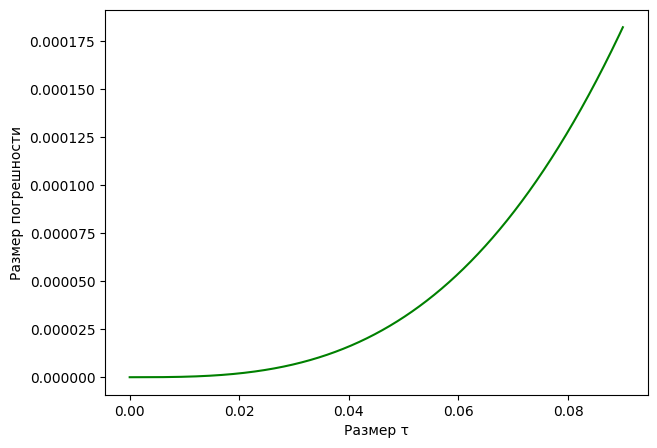

In [ ]:
fig = plt.figure(figsize=(7, 5))
ax = fig.subplots(1,1)
ax.set_xlabel("Размер τ")
ax.set_ylabel("Размер погрешности")
ax.plot(tau_array,tau_errors, color="green", label="Ошибка")

In [ ]:
print(f"Погрешность метода при τ = 0.001: {tau_error(0.001)}")
print(f"Погрешность метода при τ = 0.0001: {tau_error(0.0001)}")

Погрешность метода при τ = 0.001: 2.5022204460492505e-10
Погрешность метода при τ = 0.0001: 4.720446049250314e-13


In [ ]:
tau_error(tau)

2.5022204460492505e-10

#### Вывод о погрешностях

Из аналитических рассчётов видно, что погрешность метода зависит от шага кубически. Такой результат соответствует желаемому третьему порядку точности.

Также видно, что машинная погрешность достаточно маленькая, но при размере шага < 0.0001, машинная погрешность становится больше погрешности метода.